In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import timeit
import json
from itertools import product
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.patches as patches
import math
from copy import deepcopy
import pickle
import heapq
from matplotlib.colors import to_rgb

plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.size'] = 10
cmap_models = cm.get_cmap('Set2') 

import warnings
warnings.filterwarnings("ignore")

# Use BADS
import concurrent.futures
from pybads import BADS

import json
import pandas
from collections import Counter

from scipy.stats import binomtest, ttest_rel
import matplotlib.patches as mpatches

import sys
print(sys.version)

pd.set_option('display.max_rows', None)

figpath = os.path.join("fig")
utilpath = os.path.join("utils")

DARK2_SET3_16 = [
    '#1b9e77', '#d95f02', '#7570b3', '#e7298a',
    '#66a61e', '#e6ab02', '#a6761d', '#666666',
    '#8dd3c7', '#ffffb3', '#bebada', '#fb8072',
    '#80b1d3', '#fdb462', '#b3de69', '#fccde5'
] 


3.11.3 (main, Apr 20 2026, 15:44:30) [Clang 21.0.0 (clang-2100.0.123.102)]


/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81286/2568196935.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_models = cm.get_cmap('Set2')  # Replace 'viridis' with your desired colormap


## Maze generation

In [2]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt


def generate_maze(width, height):
    """
    Generate a rectangular maze of size `width`×`height` cells.
    Walls are "#", passages are ".". Entrance on the top row,
    exit on the bottom row.
    Returns: list of strings.
    """
    gw, gh = width * 2 + 1, height * 2 + 1
    maze = [['#'] * gw for _ in range(gh)]
    visited = [[False] * width for _ in range(height)]
    dirs = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    def carve(x, y):
        visited[y][x] = True
        maze[2*y+1][2*x+1] = '.'
        random.shuffle(dirs)
        for dx, dy in dirs:
            nx, ny = x + dx, y + dy
            if 0 <= nx < width and 0 <= ny < height and not visited[ny][nx]:
                # knock down wall
                maze[2*y+1 + dy][2*x+1 + dx] = '.'
                carve(nx, ny)

    carve(random.randrange(width), random.randrange(height))

    # entrance & exit
    entr_x = random.randrange(width) * 2 + 1
    exit_x = random.randrange(width) * 2 + 1
    maze[0][entr_x] = 'S'
    maze[-1][exit_x] = 'G'

    return [''.join(row) for row in maze]

def print_maze(maze):
    """Print the maze (list of strings) to stdout."""
    for row in maze:
        print(row)

def solve_maze_bfs(maze, start=None, end=None):
    """
    Find a shortest path from the entrance (top row) to the exit (bottom row)
    via BFS. Returns a list of (x, y) coordinates in grid indices.
    """
    h, w = len(maze), len(maze[0])

    # locate entrance and exit
    if(start is None):
        for x in range(w):
            if maze[0][x] == '.':
                start = (x, 0)
                break
        for x in range(w):
            if maze[h-1][x] == '.':
                end = (x, h-1)
                break
    # BFS
    queue = deque([start])
    parents = {start: None}
    moves = [(-1,0),(1,0),(0,-1),(0,1)]
    while queue:
        y, x = queue.popleft()
        if (y, x) == end:
            break
        for dy, dx in moves:
            ny, nx = y+dy, x+dx
            if 0 <= ny < h and 0 <= nx < w and maze[ny][nx]=='.' and (ny,nx) not in parents:
                parents[(ny,nx)] = (y,x)
                queue.append((ny,nx))

    # backtrack from end to start
    path = []
    node = end
    while node is not None:
        py, px = node
        # note: for plotting, we'll use (x, y)
        path.append((px, py))
        node = parents[node]
    path.reverse()
    return path


def solve_maze_dp(maze, start=None, end=None):
    """
    Solve the maze by dynamic programming (value iteration):
    1) Initialize dist[y][x] = infinity for all open cells, except
       dist[exit] = 0.
    2) Repeatedly sweep over all open cells, setting
       dist[y][x] = 1 + min(dist of its open neighbors),
       until no distances change.
    3) Reconstruct a shortest path from entrance to exit by
       always stepping to the neighbor with smallest dist.
    Returns: list of (x, y) coordinates of the path.
    """
    h, w = len(maze), len(maze[0])
    inf = float('inf')

    # 1. locate entrance and exit
    if(start is None):
        for x in range(w):
            if maze[0][x] == '.':
                start = (x, 0)
                break
        for x in range(w):
            if maze[h-1][x] == '.':
                end = (x, h-1)
                break

    # 2. initialize distance grid
    dist = [[inf]*w for _ in range(h)]
    ex, ey = end
    dist[ey][ex] = 0

    moves = [(-1,0),(1,0),(0,-1),(0,1)]
    changed = True
    # 3. sweep until convergence
    while changed:
        changed = False
        for y in range(h):
            for x in range(w):
                if maze[y][x] == '.' and (x,y) != end:
                    # find best neighbor
                    best = inf
                    for dx, dy in moves:
                        nx, ny = x+dx, y+dy
                        if 0 <= nx < w and 0 <= ny < h and maze[ny][nx]=='.':
                            if dist[ny][nx] < best:
                                best = dist[ny][nx]
                    # relax
                    if best + 1 < dist[y][x]:
                        dist[y][x] = best + 1
                        changed = True

    # 4. backtrack to build path
    path = []
    x, y = start
    while (x, y) != end:
        path.append((x, y))
        # pick neighbor with smallest dist
        nxt = min(
            ((x+dx, y+dy) for dx,dy in moves
             if 0 <= x+dx < w and 0 <= y+dy < h and maze[y+dy][x+dx]=='.'),
            key=lambda pos: dist[pos[1]][pos[0]]
        )
        x, y = nxt
    path.append(end)

    return path

def solve_maze_BestFirstSearch(maze, start=None, end=None, heuristic="Manhattan"):
    """
    Perform greedy best-first search on a rectangular maze.

    Parameters
    ----------
    maze : List[str]
        Maze represented as a list of strings of equal length.
        maze[row][col] == '#' for walls, '.' for free space.
    start : (col, row)
        Tuple giving the starting cell coordinates.
    end : (col, row)
        Tuple giving the end cell coordinates.
    heuristic: "Manhattan" or "Euclidean"
        Heuristic value function used to guide which square to evaluate next. 

    Returns
    -------
    path : List[(col, row)]
        The sequence of cells from start to end (inclusive), or [] if none found.
    evaluated : List[(col, row)]
        The cells popped from the priority queue, in order of expansion.
    walls : List[(col, row)]
        All wall‐cells that were examined as neighbors during the search.
    """
    width  = len(maze[0])
    height = len(maze)
    
    if(start is None):
        for x in range(width):
            if maze[0][x] == '.':
                start = (x, 0)
                break
        for x in range(width):
            if maze[height-1][x] == '.':
                end = (x, height-1)
                break

    def h(cell, distance="Manhattan"):
        c, r = cell
        gc, gr = end
        if(distance=="Manhattan"):
            return abs(c - gc) + abs(r - gr)
        elif(distance=="Euclidean"):
            return np.sqrt((c - gc)**2 + (r - gr)**2)

    # Min-heap of (priority, (col, row))
    frontier = [(h(start, distance=heuristic), start)]
    came_from = {start: None}
    visited   = {start}
    evaluated  = []
    walls      = []

    while frontier:
        _, current = heapq.heappop(frontier)
        evaluated.append(current)

        if current == end:
            break

        c, r = current
        for dc, dr in [(0,-1), (0,1), (-1,0), (1,0)]:
            nc, nr = c + dc, r + dr
            if not (0 <= nc < width and 0 <= nr < height):
                continue

            neighbor = (nc, nr)
            if neighbor in visited:
                continue

            if maze[nr][nc] == '#':
                walls.append(neighbor)
                continue

            visited.add(neighbor)
            came_from[neighbor] = current
            heapq.heappush(frontier, (h(neighbor, distance=heuristic), neighbor))

    # Reconstruct path
    path = []
    if end in came_from:
        node = end
        while node is not None:
            path.append(node)
            node = came_from[node]
        path.reverse()

    return path, evaluated, walls


def visualize_maze(maze, figsize=None, start_goal=False, path=None):
    """
    Plot the maze grid:
      - walls ("#") as black
      - passages (".") as white
      - optional: overlay `path` (list of (x,y)) as a red line.
    """
    arr = np.array([[0 if cell=='#' else 1 for cell in row] for row in maze])
    
    if figsize is None:
        plt.figure(figsize=(arr.shape[1]/5, arr.shape[0]/5))
    else:
        plt.figure(figsize=(figsize[0], figsize[1]))
    plt.imshow(arr, cmap='gray', interpolation='nearest')
    plt.xticks([]); plt.yticks([])


    if(path):
        xs, ys = zip(*path)
        plt.plot(xs[0], ys[0], '.', color='red', markersize=20)
        plt.plot(xs[-1], ys[-1], '*', color='red', markersize=12)
        if(not start_goal): # Visualize only start and end points of the maze, not path
            plt.plot(xs, ys, color='red', linewidth=2)

    plt.show()
    
    

def visualize_maze_colored(maze,
                           num_colors,
                           figsize=None,
                           start_goal=False,
                           path=None,
                           legend=False,
                           palette_name='dark2_set3',
                           adj_sq_notsamecolor = True,
                           plt_show=True):
    """
    Visualize a maze with randomly assigned colors; but ensure no two
    adjacent cells of the same type share a color (greedy coloring).
    Parameters:
      - maze: list of strings ('#' walls, other symbols are all passages)
      - num_colors: total number of colors (must be >=2 and even)
      - figsize: tuple for figure size
      - start_goal: if True mark only start/end, else draw full path
      - path: list of (x,y) coordinates to overlay
      - legend: whether to draw the maze+legend (True) or just the maze (False)
      - palette_name: Matplotlib colormap name, e.g. 'tab20' or 'gray'
      - adj_sq_notsamecolor: if True, ensure no two adjacent cells of the same type share a color.
      - plt_show: if True, calls plt.show(); else leaves the figure open for saving downstream
    """
    # Randomize colors for each trial
    half = num_colors // 2
    
    if palette_name == "dark2_set3":
        if num_colors > len(DARK2_SET3_16):
            raise ValueError(
                f"num_colors={num_colors} exceeds the custom palette size "
                f"of {len(DARK2_SET3_16)}."
            )
    
        colors = random.sample(DARK2_SET3_16, num_colors)
        colors = [to_rgb(c) for c in colors]
    
        wall_colors = colors[:half]
        passage_colors = colors[half:num_colors]
    
    elif palette_name != "gray":
        cmap = plt.get_cmap(palette_name)
    
        if hasattr(cmap, "colors"):
            base_colors = list(cmap.colors)
    
            if num_colors > len(base_colors):
                raise ValueError(
                    f"num_colors={num_colors} exceeds palette size "
                    f"of {len(base_colors)} for palette_name='{palette_name}'."
                )
    
            colors = random.sample(base_colors, num_colors)
        else:
            positions = np.linspace(0, 1, num_colors)
            colors = [cmap(pos) for pos in positions]
            random.shuffle(colors)
    
        wall_colors = colors[:half]
        passage_colors = colors[half:num_colors]
    
    else:  # Black and white maze
        cmap = plt.get_cmap("gray")
        positions = np.linspace(0, 1, num_colors)
        colors = [cmap(pos) for pos in positions]
    
        wall_colors = colors[0:half]
        passage_colors = colors[-half:]

    H, W = len(maze), len(maze[0])
    # 2) Greedy coloring: no same‐type neighbors share a color
    img = np.zeros((H, W, 3), dtype=float)
    
    if(adj_sq_notsamecolor): # Ensure that no adjacent squares share the same color. Works only with num_colors>=8, due to the four-color theorem.
        assigned = [[None]*W for _ in range(H)]
        for y in range(H):
            for x in range(W):
                palette = wall_colors if maze[y][x] == '#' else passage_colors
                # collect forbidden from up and left if same type
                forbidden = set()
                for dy, dx in [(-1,0),(0,-1)]:
                    ny, nx = y+dy, x+dx
                    if 0 <= ny < H and 0 <= nx < W and maze[ny][nx] == maze[y][x]:
                        c = assigned[ny][nx]
                        if c is not None:
                            forbidden.add(c)
                # choose from palette avoiding forbidden
                choices = [c for c in palette if c not in forbidden]
                chosen = random.choice(choices) if choices else random.choice(palette)
                assigned[y][x] = chosen
                img[y, x] = chosen[:3]
    else:
        for y in range(H):
            for x in range(W):
                if maze[y][x] == '#':
                    color = random.choice(wall_colors)
                else:
                    color = random.choice(passage_colors)
                img[y, x] = color[:3]  # drop alpha channel

    # 3) Display
    if not legend:
        if figsize is None:
            plt.figure(figsize=(W/5, H/5))
        else:
            plt.figure(figsize=figsize)
        plt.imshow(img, interpolation='nearest')
        plt.xticks([]); plt.yticks([])
        if path:
            xs, ys = zip(*path)
            plt.plot(xs[0], ys[0], '.', color='red', markersize=20)
            plt.plot(xs[-1], ys[-1], '*', color='red', markersize=12)
            if not start_goal:
                plt.plot(xs, ys, color='red', linewidth=2)
        if plt_show:
            plt.show()
    else:
        # maze+legend side by side
        if figsize is None:
            figsize = ((W + half)/5, H/5)
        fig, (ax_maze, ax_leg) = plt.subplots(
            1, 2,
            figsize=figsize,
            gridspec_kw={'width_ratios': [W, max(8, num_colors)//2 * 1.2],
                         'wspace': 0.25}
        )
        # draw maze
        ax_maze.imshow(img, interpolation='nearest')
        ax_maze.set_xticks([]); ax_maze.set_yticks([])
        ax_maze.set_aspect('equal')
        if path:
            xs, ys = zip(*path)
            ax_maze.plot(xs[0], ys[0], '.', color='red', markersize=20)
            ax_maze.plot(xs[-1], ys[-1], '*', color='red', markersize=12)
            if not start_goal: # Visualize only start and end points of the maze, not path
                ax_maze.plot(xs, ys, color='red', linewidth=2)

        # draw legend
        legend_size = 1.5
        ax_leg.axis('off')
        ax_leg.set_aspect('equal')
        ax_leg.set_xlim(-1, (max(8, num_colors)//2 + 0.2)*legend_size)
        ax_leg.set_ylim(-2*legend_size, 3*legend_size)

        row_gap = 0.75
        # walls row
        for i, col in enumerate(wall_colors):
            ax_leg.add_patch(patches.Rectangle(
                (i*legend_size, legend_size + row_gap),
                legend_size, legend_size,
                facecolor=col[:3], edgecolor='k'
            ))
        ax_leg.text(-0.5, legend_size*1.5+row_gap, 'Danger:',
                    va='center', ha='right', fontsize=10)
        # spaces row
        for i, col in enumerate(passage_colors):
            ax_leg.add_patch(patches.Rectangle(
                (i*legend_size, 0),
                legend_size, legend_size,
                facecolor=col[:3], edgecolor='k'
            ))
        ax_leg.text(-0.5, legend_size*0.5, 'Safety:',
                    va='center', ha='right', fontsize=10)

        if plt_show:
            plt.show()
        else:
            fig.tight_layout()

    return {"ax_maze":ax_maze, "wall_colors": wall_colors,
            "passage_colors": passage_colors}



# if __name__ == '__main__':
#     w = int(input("Enter maze width (cells): "))
#     h = int(input("Enter maze height (cells): "))
#     m = generate_maze(w, h)
#     p = solve_maze(m)
#     visualize_maze(m, p)


In [3]:
import random
from collections import deque

def generate_maze_perimeter(width, height, thres = 1):
    """
    Generate a rectangular maze of size `width`×`height` cells such that:
      - Entrance is always at the top-center.
      - Exit    is always at the bottom-center.
      - half_perimeter is defined as the path length to go around the maze, from start to end location. 
      - The shortest path length satifies maze_height < length < (thres * perimeter / 2).
    

    Returns a list of strings, where '#' are walls and '.' are passages.
    """
    gw, gh = width * 2 + 1, height * 2 + 1
    half_perimeter = gw + gh + 2 # Rim path
    half_perimeter = half_perimeter + 2 # Need to move one step ahead along the rim, and then step in from rim to goal. 

    def carve_grid():
        # carve out a perfect maze (no entrance/exit yet)
        maze = [['#'] * gw for _ in range(gh)]
        visited = [[False] * width for _ in range(height)]
        dirs = [(-1,0),(1,0),(0,-1),(0,1)]

        def carve(x, y):
            visited[y][x] = True
            maze[2*y+1][2*x+1] = '.'
            random.shuffle(dirs)
            for dx, dy in dirs:
                nx, ny = x+dx, y+dy
                if 0 <= nx < width and 0 <= ny < height and not visited[ny][nx]:
                    maze[2*y+1 + dy][2*x+1 + dx] = '.'
                    carve(nx, ny)

        # start carving from a random cell
        carve(random.randrange(width), random.randrange(height))
        return maze

    def shortest_path_length(maze):
        # BFS from top-center to bottom-center
        start = (0, gw//2)
        end   = (gh-1, gw//2)
        q = deque([start])
        dist = {start: 0}
        while q:
            y, x = q.popleft()
            if (y, x) == end:
                return dist[(y, x)]
            for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
                ny, nx = y+dy, x+dx
                if 0 <= ny < gh and 0 <= nx < gw and maze[ny][nx]=='.' and (ny,nx) not in dist:
                    dist[(ny, nx)] = dist[(y, x)] + 1
                    q.append((ny, nx))
        return float('inf')

    while True:
        grid = carve_grid()

        # enforce fixed entrance / exit
        grid[0][gw//2]     = '.' # start
        grid[gh-1][gw//2] = '.' # goal

        # stringify for solver
        maze = [''.join(row) for row in grid]

        if (shortest_path_length(maze) < (thres * half_perimeter) and shortest_path_length(maze) >= gh):
            return maze

def maze_add_perimeters(maze, random_block_route=False, block_route_prob = 0.3, block_square_prob = 0.2):
    '''Adds a rim of white spaces around a maze.
        random_block_route with block either half-perimeter path (Denoted +'s or -'s) with independent probs.'''
    height = len(maze)
    width = len(maze[0])
    maze_new = deepcopy(maze)
    top_bottom_rows = "".join(['+' for m in range(width//2)] + ['.'] + ['-' for m in range(width//2+1, width)])
    maze_new.insert(0, top_bottom_rows)
    maze_new.append(top_bottom_rows)
    maze_new = ['+'+m+'-' for m in maze_new]
    
#     if(random_block_route): # Sometimes block one or two periphery paths
#         if(random.random()<block_route_prob): # Left route blocked
#             # Change some of the +'s to #. 
#         if(random.random()<block_route_prob): # Right route blocked
#             # Change some of the -'s to #.

    if(random_block_route):
        # block the '+' rim?
        if(random.random() < block_route_prob):
            new_rows = []
            for row in maze_new:
                # replace each '+' with '#' w.p. 1/5
                new_row = ''.join(
                    '#' if (ch == '+' and random.random() < block_square_prob) else ch
                    for ch in row
                )
                new_rows.append(new_row)
            maze_new = new_rows

        # block the '-' rim?
        if(random.random() < block_route_prob):
            new_rows = []
            for row in maze_new:
                # replace each '-' with '#' w.p. 1/5
                new_row = ''.join(
                    '#' if (ch == '-' and random.random() < block_square_prob) else ch
                    for ch in row
                )
                new_rows.append(new_row)
            maze_new = new_rows
        
    return maze_new

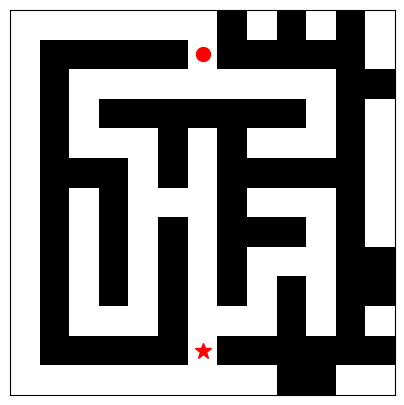

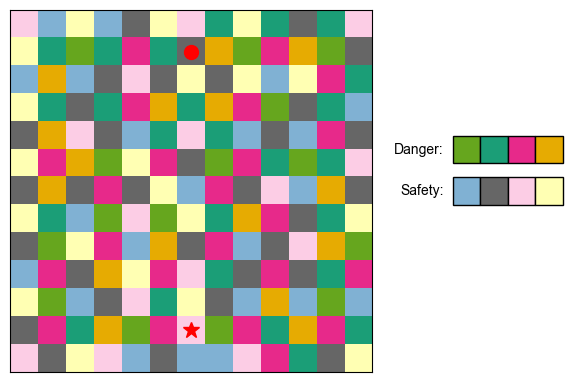

In [4]:
# The above code uses the random package, not numpy.random! Important for seed-setting
random.seed(0)
m_raw = generate_maze_perimeter(5, 5, thres=0.8)
m = maze_add_perimeters(m_raw, random_block_route=True, block_route_prob = 0.3, block_square_prob = 0.2)
start = (len(m[0])//2, 1)
end = (len(m[0])//2, len(m[0])-2)

p = solve_maze_dp(m, start=start, end=end)
visualize_maze(m, figsize=(5,5), start_goal=True, path=p)
# color_palette = visualize_maze_colored(m, num_colors=4, figsize=(5,5), path=p)
# color_palette = visualize_maze_colored(m, num_colors=8, figsize=(5,5), path=p)
color_palette = visualize_maze_colored(m, num_colors=8, figsize=(7.2,7.2), legend=True, start_goal=True, adj_sq_notsamecolor=True, path=p)
# #print(color_palette)

In [5]:
m

['++++++.#-#-#-',
 '+#####.#####-',
 '+#.........##',
 '+#.#######.#-',
 '+#...#.#...#-',
 '+###.#.#####-',
 '+#.#...#...#-',
 '+#.#.#.###.#-',
 '+#.#.#.#...##',
 '+#.#.#.#.#.##',
 '+#...#...#.#-',
 '+#####.######',
 '++++++.--##--']

## Generate multiple mazes

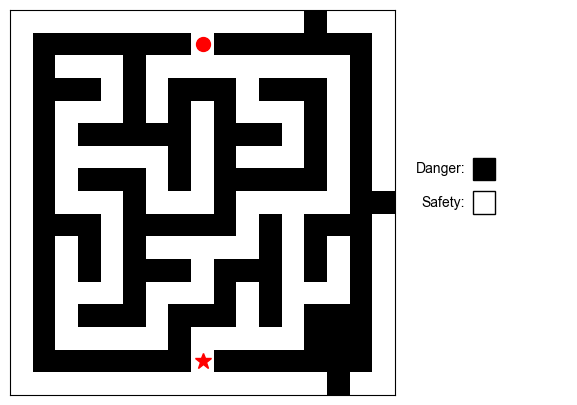

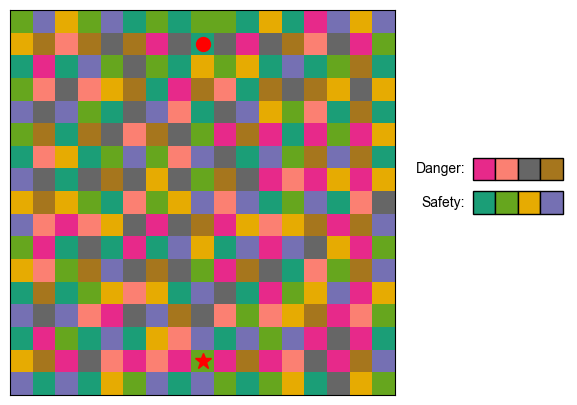

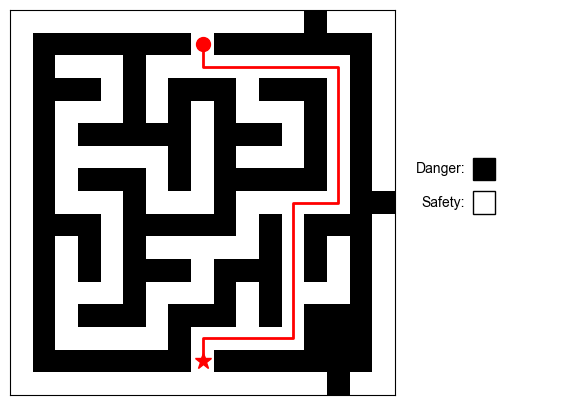

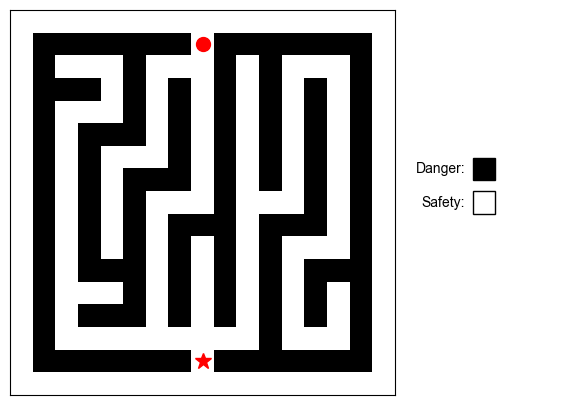

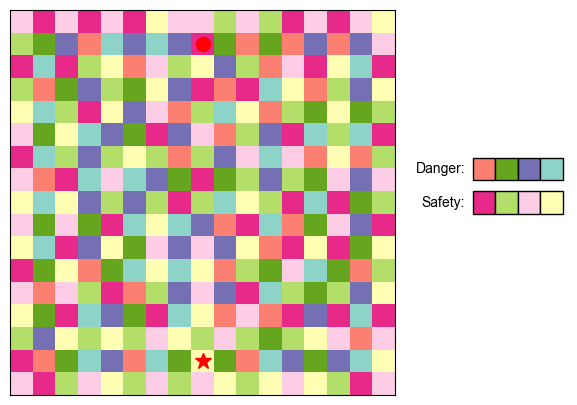

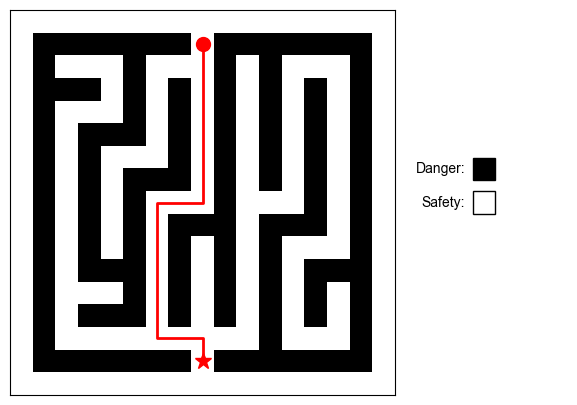

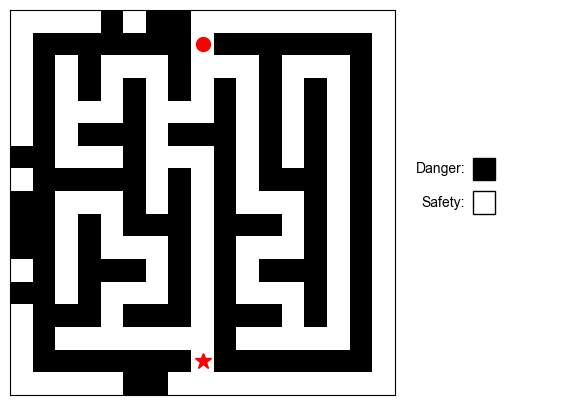

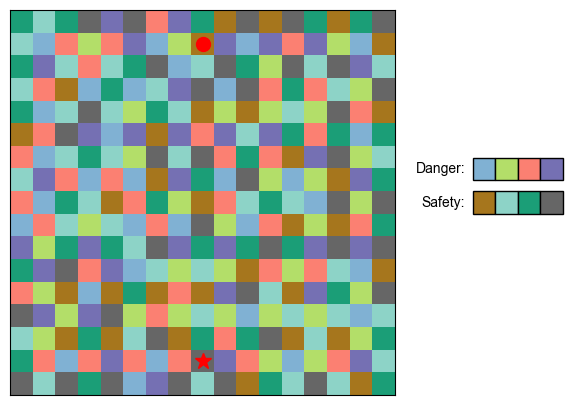

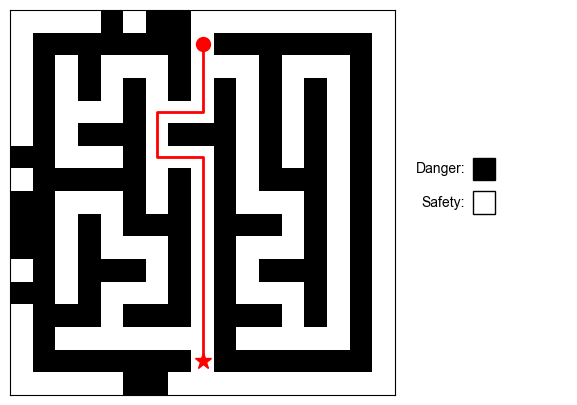

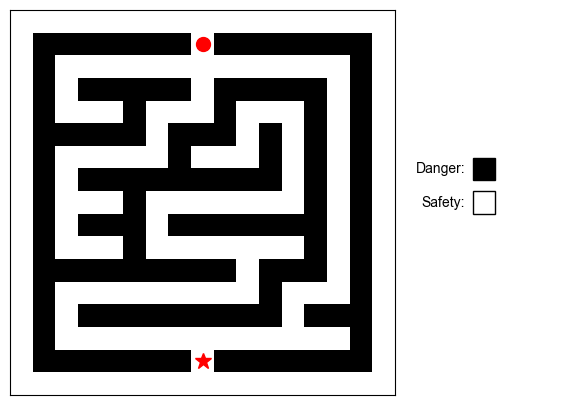

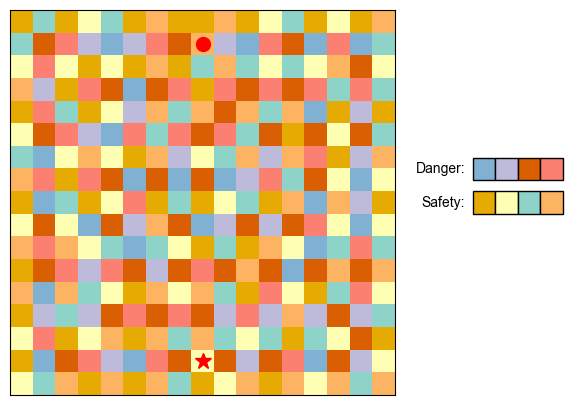

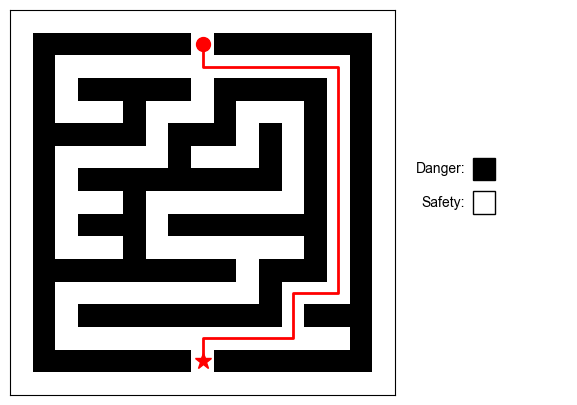

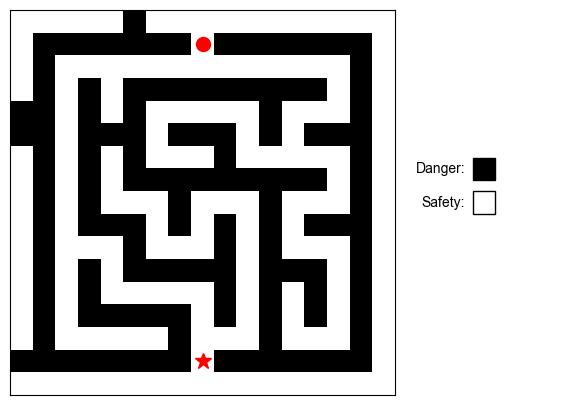

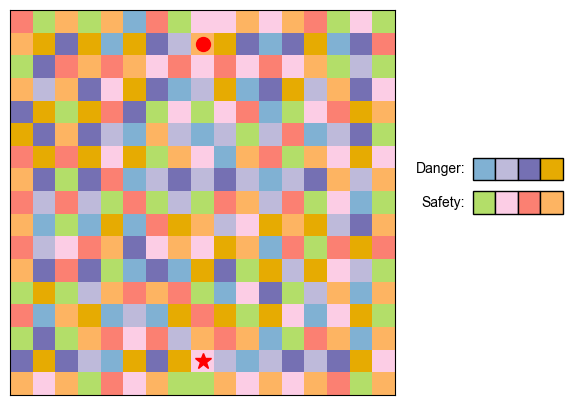

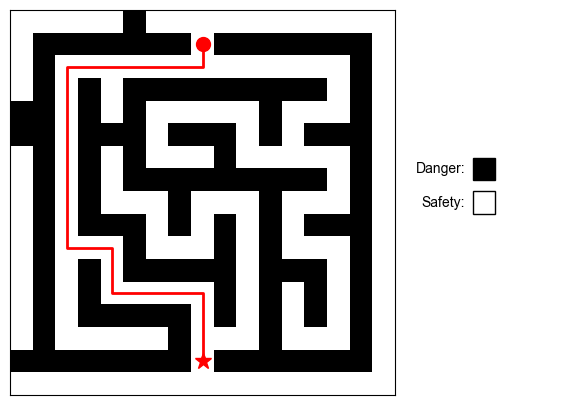

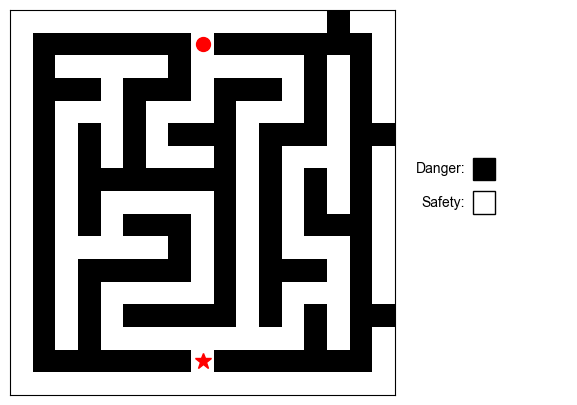

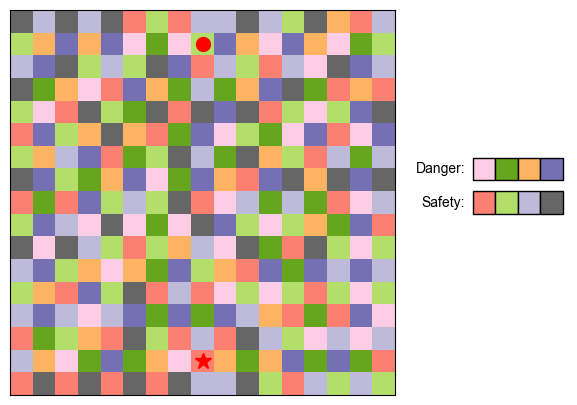

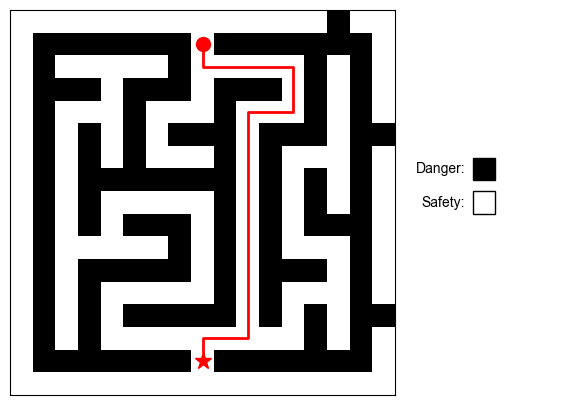

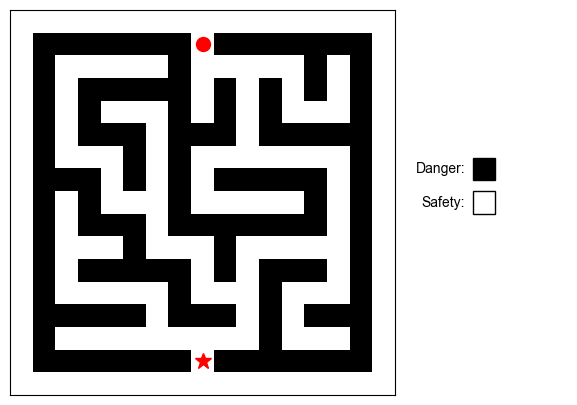

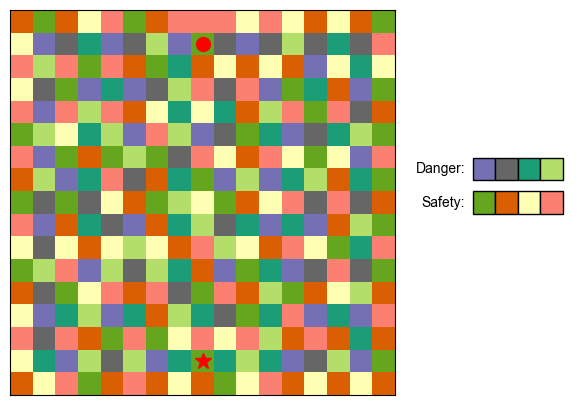

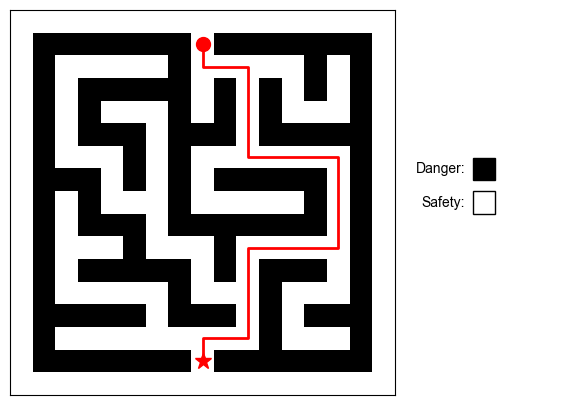

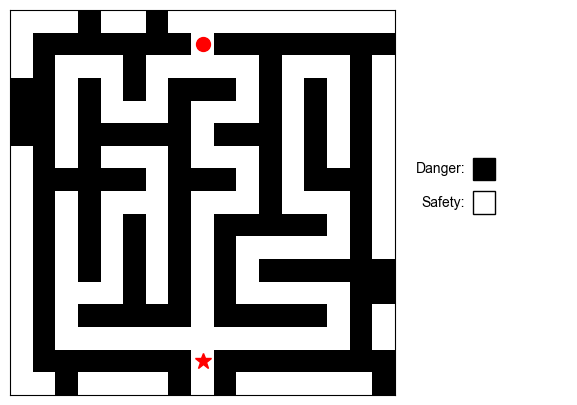

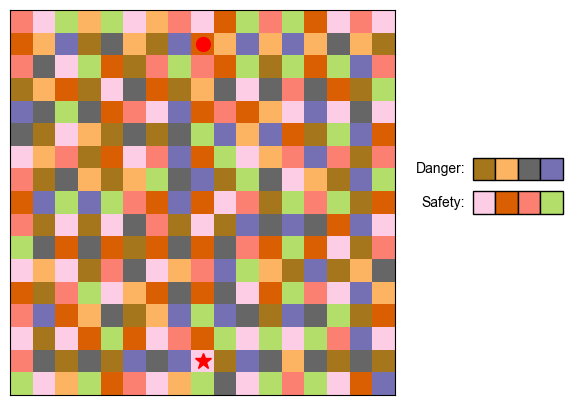

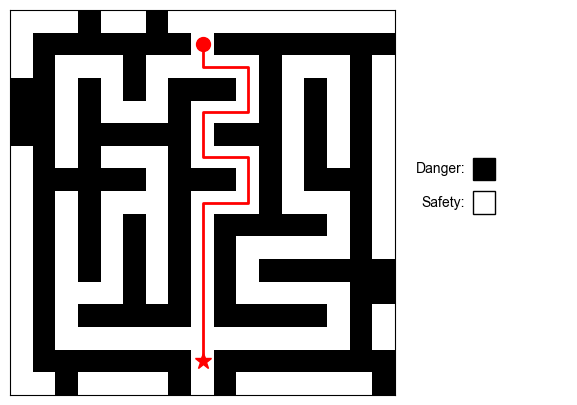

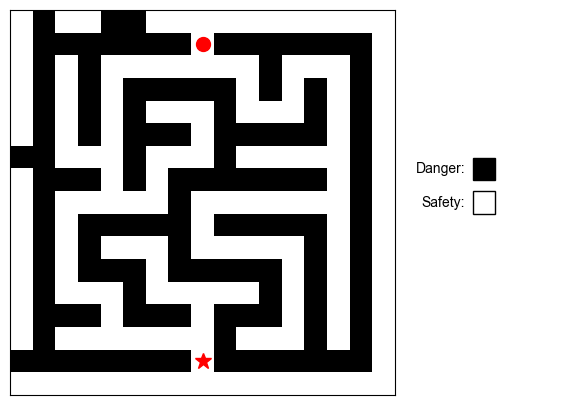

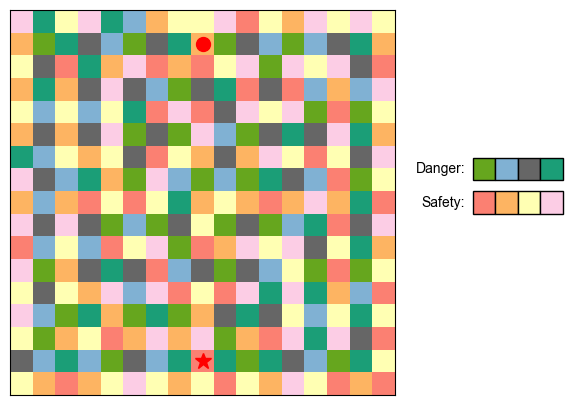

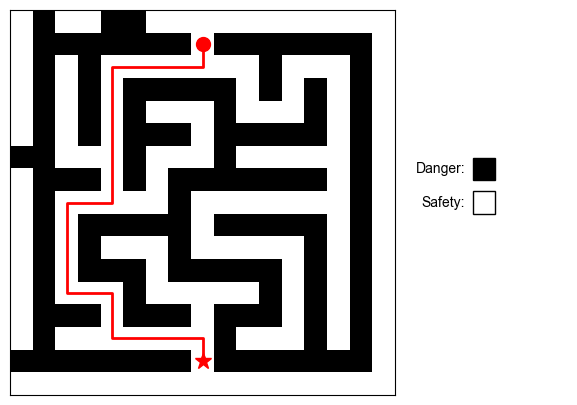

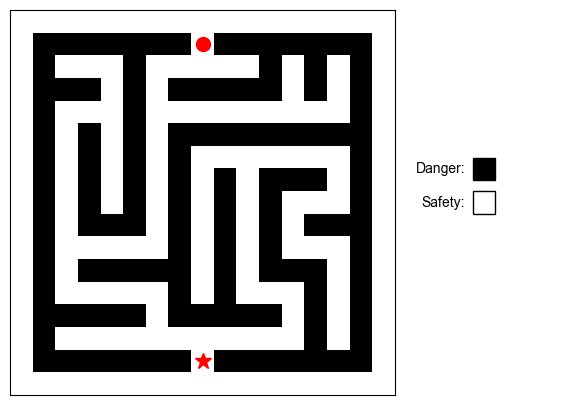

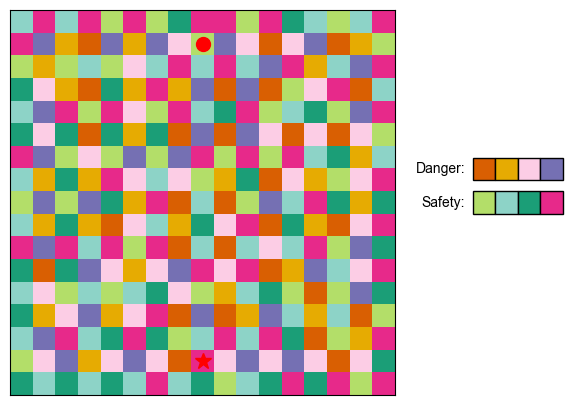

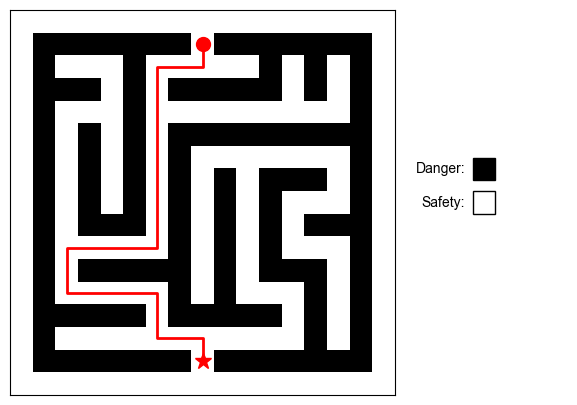

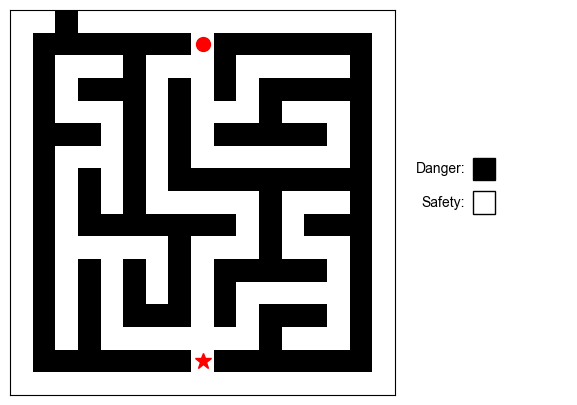

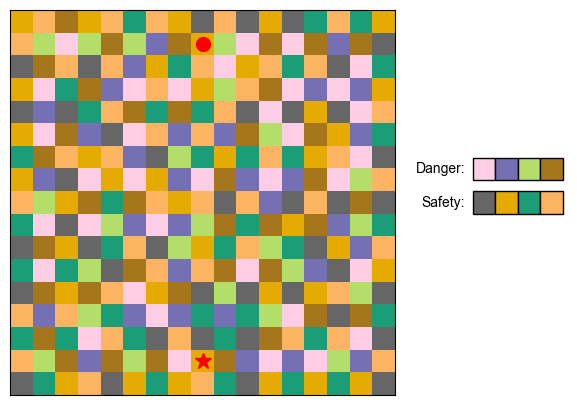

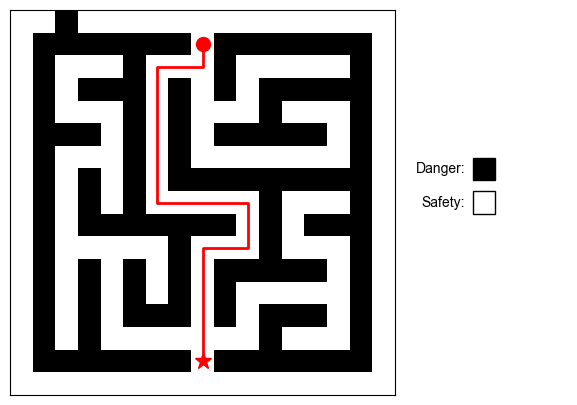

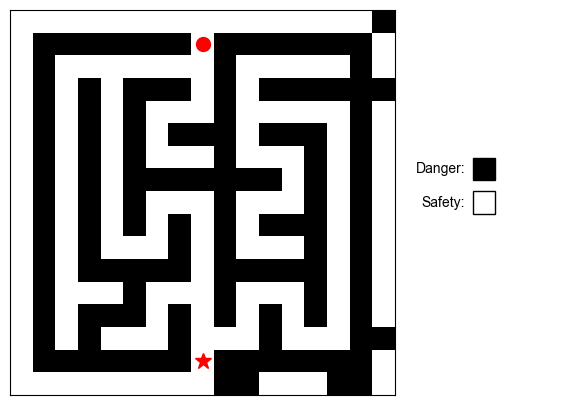

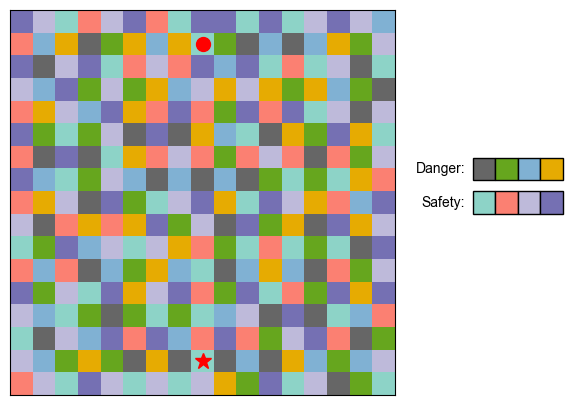

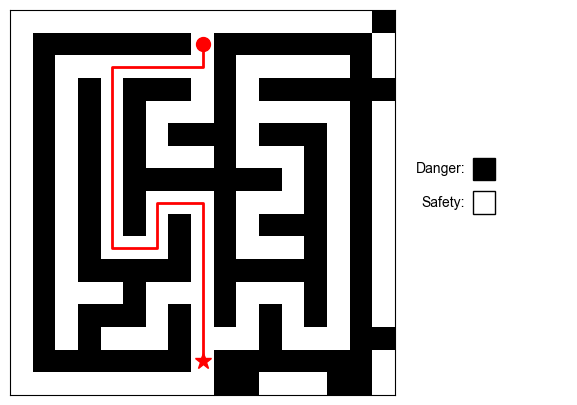

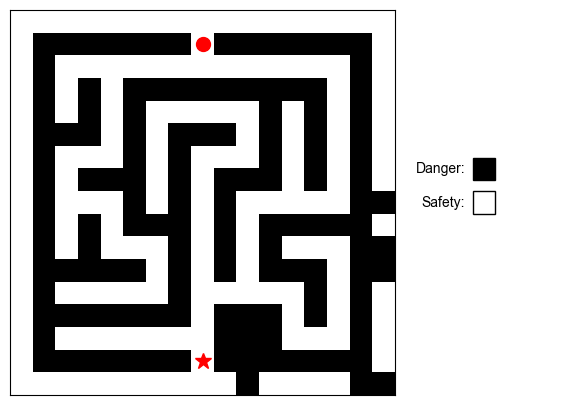

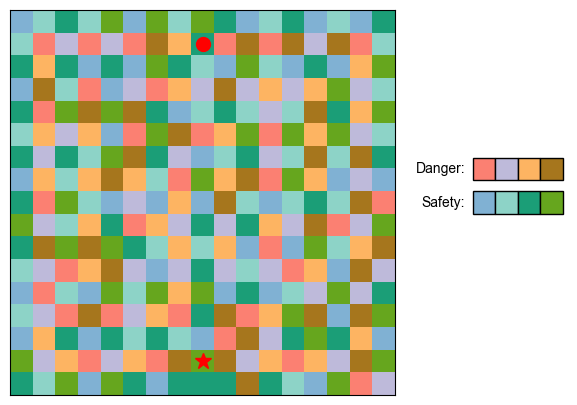

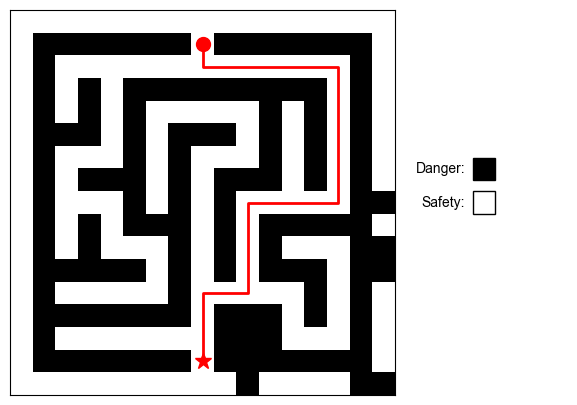

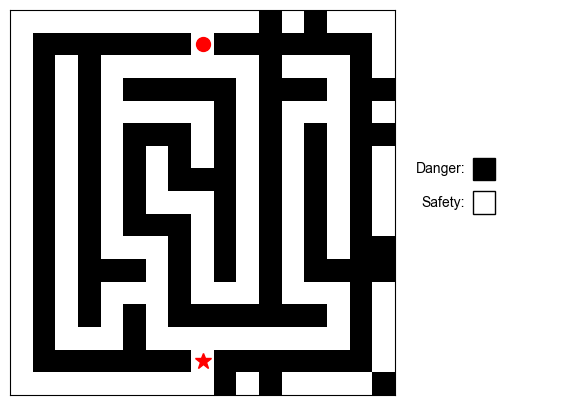

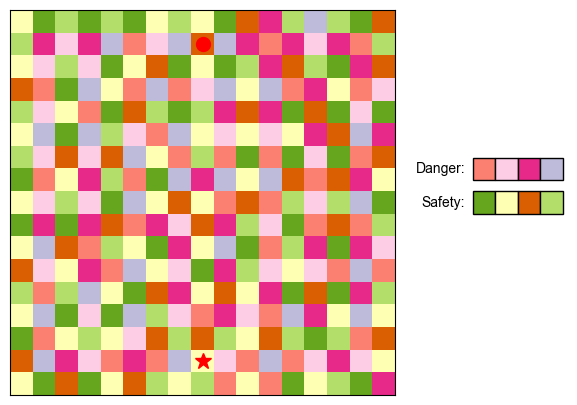

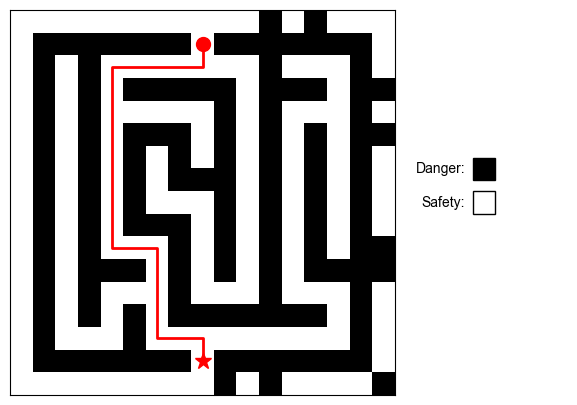

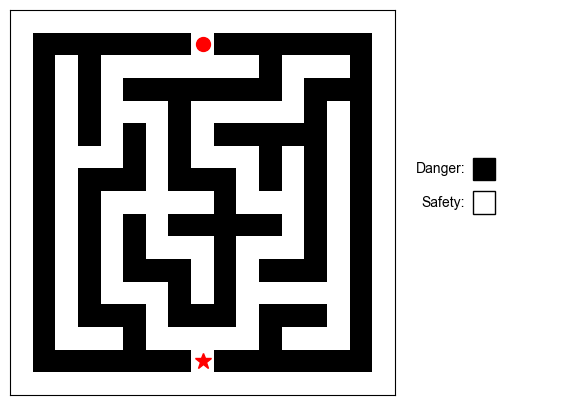

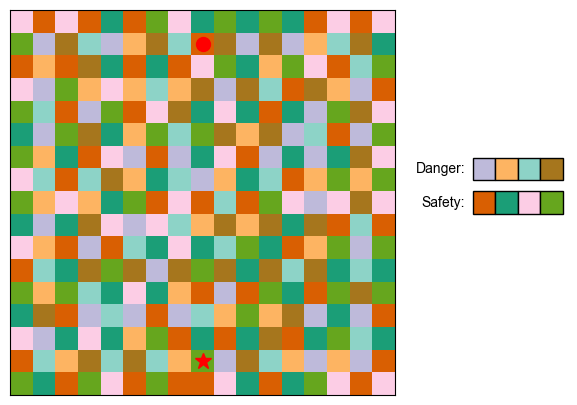

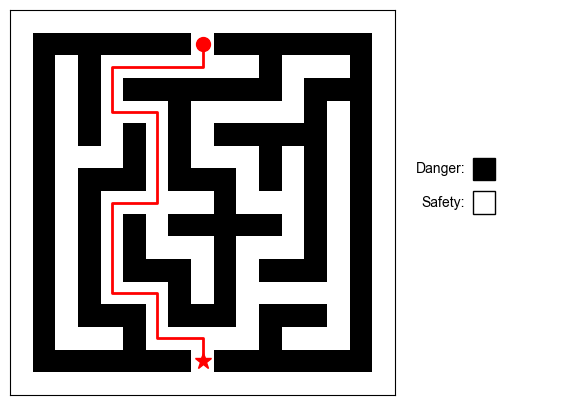

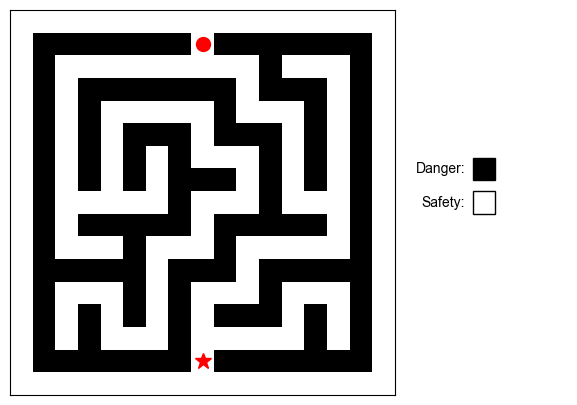

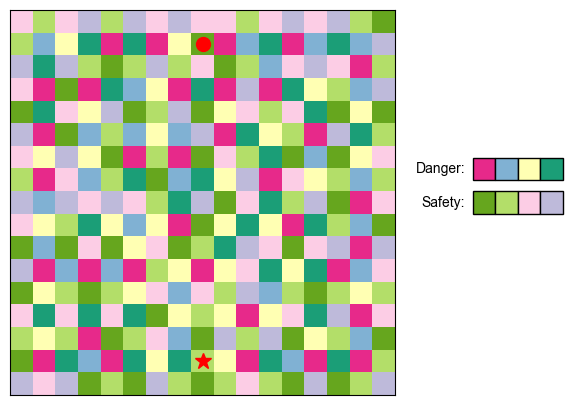

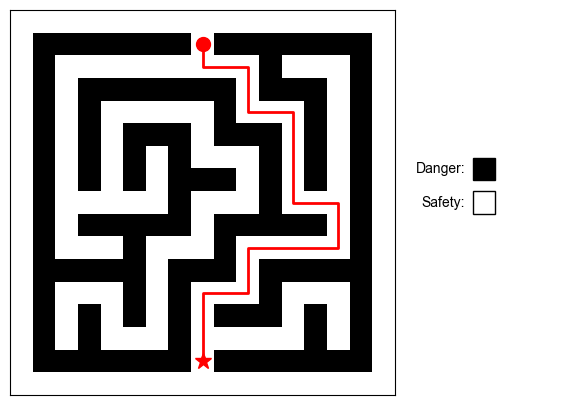

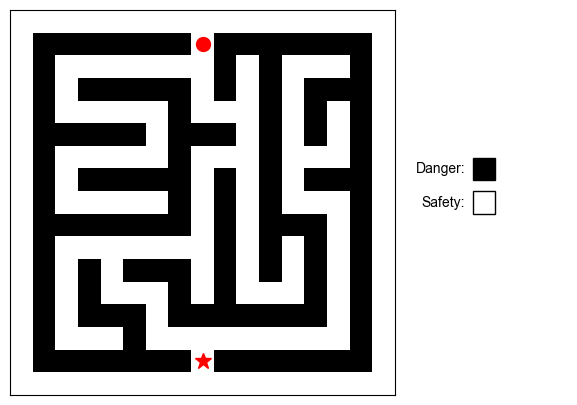

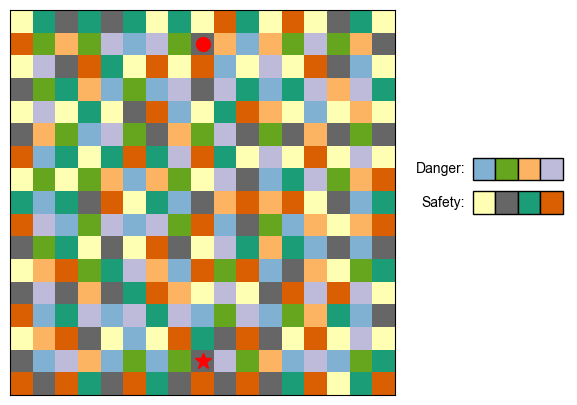

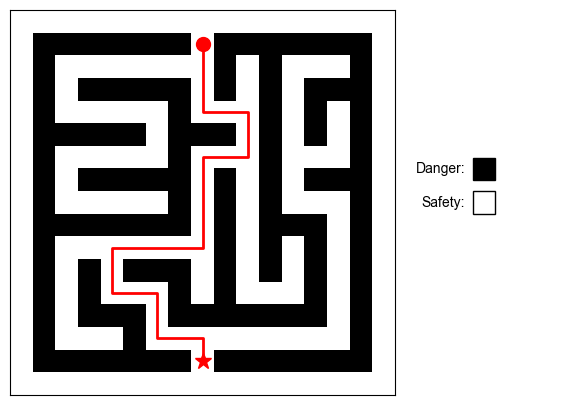

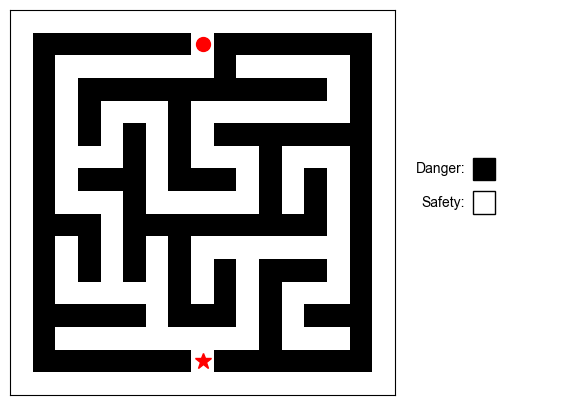

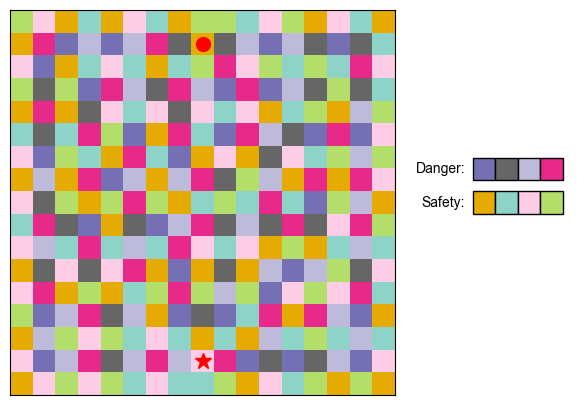

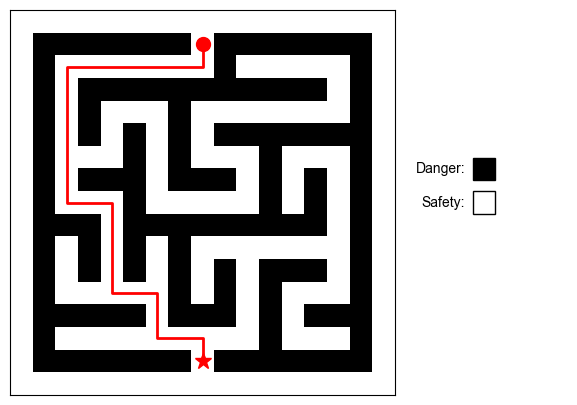

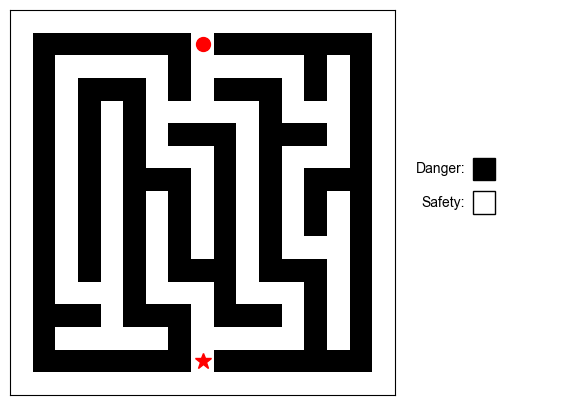

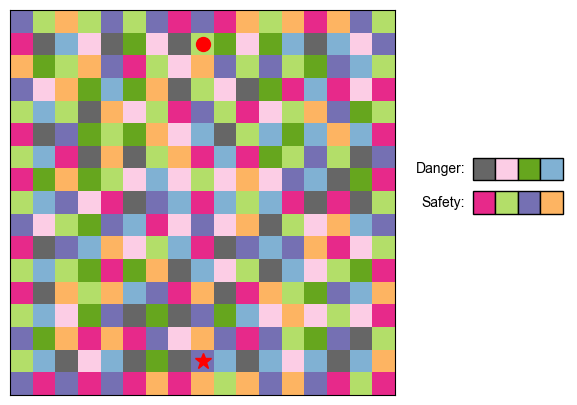

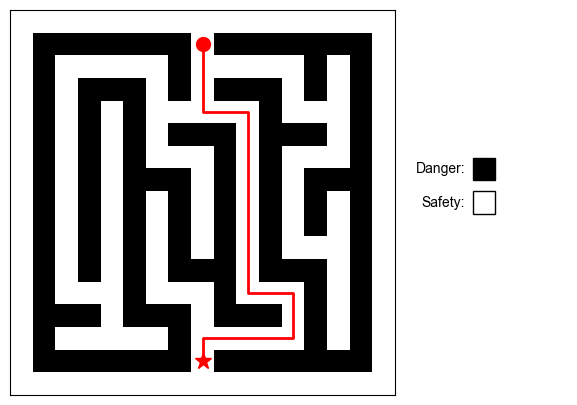

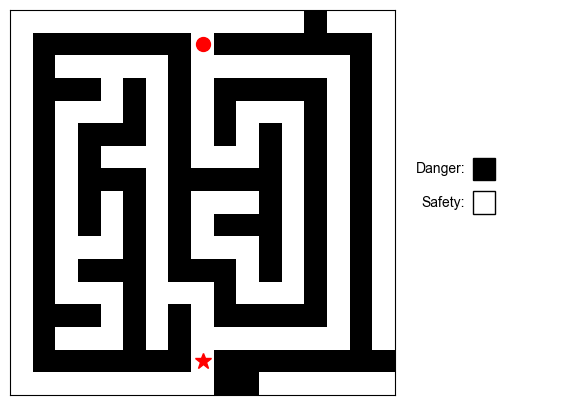

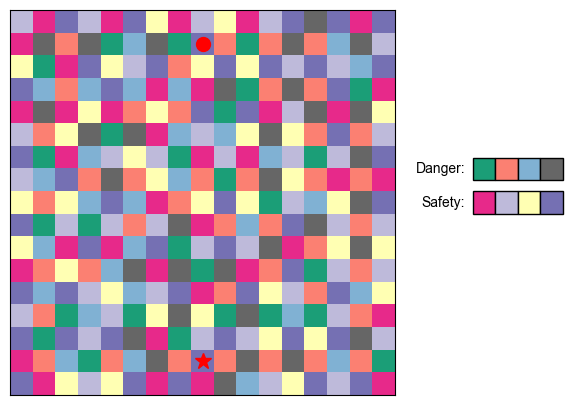

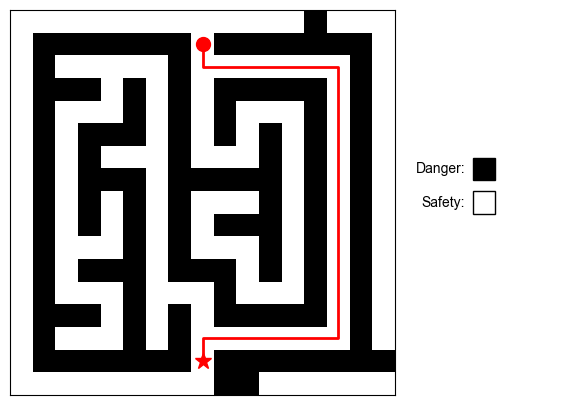

In [6]:
n_mazes = 20
maze_size = 7
rejection_thres = 0.8
mazes = []
best_paths = []
color_palettes = []

# Generate mazes
for maze_idx in range(n_mazes):
    
    # Create maze
    random.seed(maze_idx)
    m_raw = generate_maze_perimeter(maze_size, maze_size, thres=rejection_thres)
    m = maze_add_perimeters(m_raw, random_block_route=True, block_route_prob = 0.3, block_square_prob = 0.2)
    
    # Find shortest path from start to end
    start = (len(m[0])//2, 1)
    end = (len(m[0])//2, len(m[0])-2)
    p = solve_maze_dp(m, start=start, end=end)
    mazes.append(m)
    best_paths.append(p)

# Visualize_mazes
for maze_idx in range(n_mazes):
    random.seed(maze_idx)
    color_palette1 = visualize_maze_colored(mazes[maze_idx], num_colors=2, figsize=(7.2,5), legend=True, start_goal=True, path=best_paths[maze_idx], palette_name='gray', plt_show=False)
    plt.savefig(os.path.join(figpath, "maze_"+str(maze_idx)+"_0"), dpi=300)
    plt.show()
    color_palette2 = visualize_maze_colored(mazes[maze_idx], num_colors=8, figsize=(7.2,5), legend=True, start_goal=True, path=best_paths[maze_idx], plt_show=False)
    plt.savefig(os.path.join(figpath, "maze_"+str(maze_idx)+"_1"), dpi=300)
    plt.show()
    color_palette3 = visualize_maze_colored(mazes[maze_idx], num_colors=2, figsize=(7.2,5), legend=True, start_goal=False, path=best_paths[maze_idx], palette_name='gray', plt_show=False)
    plt.savefig(os.path.join(figpath, "maze_"+str(maze_idx)+"_sol"), dpi=300)
    plt.show()
    color_palettes.append([color_palette1, color_palette2])

# # Save maze information
# a = {"mazes":mazes, "best_paths":best_paths, "color_palettes":color_palettes, "rejection_thres":rejection_thres}
# with open(os.path.join(figpath,'mazes.pkl'), 'wb') as file:
#     pickle.dump(a, file)

## Visualization

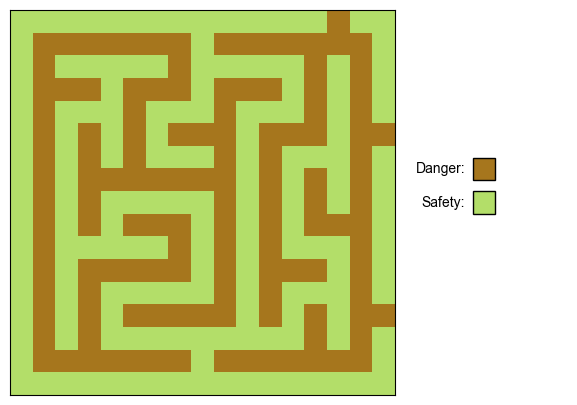

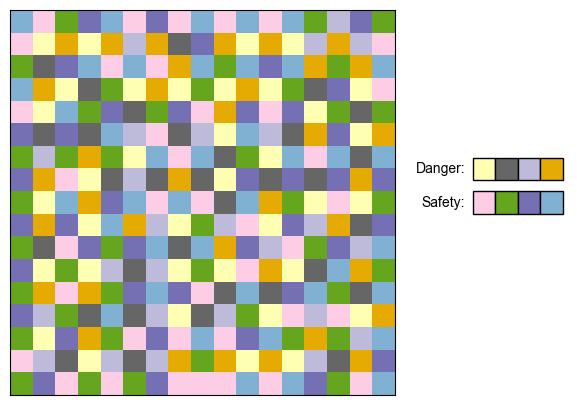

In [8]:
# Load the saved maze structures
with open(os.path.join("..","analysis","data",'test_mazes.pkl'), 'rb') as file:
    mazes = pickle.load(file)
n_mazes = len(mazes)
# Visualize_mazes
for maze_idx in [5]: #range(n_mazes)
    random.seed(101) #101
    color_palette1 = visualize_maze_colored(mazes[maze_idx], num_colors=2, figsize=(7.2,5), legend=True, start_goal=True, path=None, plt_show=False)
    plt.savefig(os.path.join(figpath, "maze_"+str(maze_idx)+"_00.eps"), format="eps")
    plt.show()
    color_palette2 = visualize_maze_colored(mazes[maze_idx], num_colors=8, figsize=(7.2,5), legend=True, start_goal=True, path=None, plt_show=False)
    plt.savefig(os.path.join(figpath, "maze_"+str(maze_idx)+"_11.eps"), format="eps")
    plt.show()
